In [1]:
# Import libraries
# ==========================================
# Standard Library & File System
# ==========================================
from pathlib import Path
import random

# ==========================================
# Jupyter Notebook / Display
# ==========================================
from IPython.display import display

# ==========================================
# 2. Data Manipulation
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ==========================================
# 3. Machine Learning & Preprocessing
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    recall_score,
    precision_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from xgboost import XGBClassifier
import shap

# Set random state variable for reproducibility
RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)


c:\Users\tbaug\OneDrive\Desktop\Drop_out_predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Establish paths
project_dir = Path.cwd()
data_path = project_dir / "data" / "student_registry_cleaned_features.csv"
if not data_path.is_file():
    raise FileNotFoundError(
        f"Could not find:\n  {data_path}\n"
        f"Current working directory: {project_dir}\n"
        "Fix: open the Drop_out_predictor folder as the workspace, or run from a terminal: "
        "`cd` to that folder then start Jupyter / run this notebook."
    )

# Load the master processed dataframe
df = pd.read_csv(data_path)

# Ensure original label is numeric (original meaning: graduated=1, dropout=0)
if df["graduated"].dtype == object:
    print("Mapping string target to numeric...")
    df["graduated"] = df["graduated"].map({"graduate": 1, "dropout": 0})

# Modeling target (clear meaning): dropout=1, not_dropout=0
y = (df["graduated"] == 0).astype(int)

print("--- Baseline Evaluation (dropout=1) ---")
print(y.value_counts(normalize=True).rename("proportion"))

# Separate Features (X) and Target (y)
X = df.drop(columns=["graduated"], errors="ignore")
X = X.drop(columns=["student_id"], errors="ignore")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"\nTraining set size: {X_train.shape[0]} students")
print(f"Testing set size: {X_test.shape[0]} students")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# Baseline model: always predicts the most common class
# (Useful to avoid being fooled by high accuracy on imbalanced data)
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train)
y_dummy_pred = dummy_clf.predict(X_test)

print("\nClassification Report for Dummy (Baseline) Model:")
print(classification_report(y_test, y_dummy_pred, zero_division=0))

--- Baseline Evaluation (dropout=1) ---
graduated
0    0.850946
1    0.149054
Name: proportion, dtype: float64

Training set size: 5920 students
Testing set size: 1480 students
X_train shape: (5920, 25)
X_test shape: (1480, 25)

Classification Report for Dummy (Baseline) Model:
              precision    recall  f1-score   support

           0       0.85      1.00      0.92      1259
           1       0.00      0.00      0.00       221

    accuracy                           0.85      1480
   macro avg       0.43      0.50      0.46      1480
weighted avg       0.72      0.85      0.78      1480



Result: This baseline model always predicts the most common outcome, so while accuracy is high, it does a poor job catching dropouts.

Takeaway: this is the "minimum bar" to beat, and it helps avoid being fooled by high accuracy when the classes are imbalanced.

In [3]:
# Shared column lists (raw features — before any encoding)
cat_cols_raw = X_train.select_dtypes(include=["object", "string", "category"]).columns.tolist()
num_cols_raw = [c for c in X_train.columns if c not in cat_cols_raw]
print(f"Categorical columns to one-hot encode: {cat_cols_raw}")

Categorical columns to one-hot encode: ['major', 'gender', 'financial_aid', 'tuition_status']


In [ ]:
# Logistic Regression- numeric columns scaled, categorical columns OHE
preprocess_lr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_raw),
        ("num", StandardScaler(), num_cols_raw),
    ],
    verbose_feature_names_out=False,
)

lr_model = LogisticRegression(
    class_weight="balanced",
    max_iter=5000,
    random_state=RANDOM_STATE,
)

lr_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_lr),
        ("model", lr_model),
    ]
)

# Train model
lr_pipe.fit(X_train, y_train)

# Predict on testset
y_pred_lr = lr_pipe.predict(X_test)
y_prob_lr = lr_pipe.predict_proba(X_test)[:, 1]  # dropout probability (class 1)

# Report dropout-focused metrics (dropout = 1)
print("--- Logistic Regression Classification Report ---")
print(classification_report(y_test, y_pred_lr, zero_division=0))

print(f"Dropout recall (class 1): {recall_score(y_test, y_pred_lr, pos_label=1):.3f}")
print(f"Dropout precision (class 1): {precision_score(y_test, y_pred_lr, pos_label=1, zero_division=0):.3f}")

cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(cm_lr)

--- Logistic Regression Classification Report ---
              precision    recall  f1-score   support

           0       0.99      0.94      0.96      1259
           1       0.73      0.94      0.82       221

    accuracy                           0.94      1480
   macro avg       0.86      0.94      0.89      1480
weighted avg       0.95      0.94      0.94      1480

Dropout recall (class 1): 0.941
Dropout precision (class 1): 0.730

Confusion matrix (rows=true [0,1], cols=pred [0,1]):
[[1182   77]
 [  13  208]]


Confusion Matrix: 
True negatives- 1182 students who graduated and were predicted to graduate;
False Positive- 77 students who graduated, but were predicted to drop out;
False Negative- 13 students who did not graduate, but were predicted to graduate;
True Positives- 208 students who did not graduate, and were predicted to not graduate.

Result: There were 221 actual dropouts in the test set and this logistic regression model sucessfully flagged 208 of them. The model correctly identified 94.1% of the actual drop-outs, so we can be confident very few students are slipping through the cracks. On the other hand, the precision level of 73% indicates that when the model flags a student as a potential drop-out, it is correct 73% of the time. The other 27% are students flagged as potential drop-outs who actually do go on to graduate (77 false alarms). This precision level could lead to wasted time and effort as well as "alert fatigue", prompting the exploration of a more nuanced model—XGBoost.

In [ ]:
# XGBoost: Pipeline on raw X_train / X_test (same pattern as Logistic Regression)
# Preprocessing runs inside the pipeline so it is fit only on training data.
# XGBoost preprocessing: one-hot categoricals, pass through numerics
preprocess_xgb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols_raw),
        ("num", "passthrough", num_cols_raw),
    ],
    verbose_feature_names_out=False,
)

# Class imbalance weight for XGBoost
# scale_pos_weight helps XGBoost prioritize the minority class
# With dropout=1, scale_pos_weight should be (non_dropouts / dropouts)
num_dropouts = int(np.sum(y_train == 1))
num_non_dropouts = int(np.sum(y_train == 0))
xgb_scale_pos_weight = num_non_dropouts / max(num_dropouts, 1)
print(f"Calculated scale_pos_weight (non_dropout/dropout): {xgb_scale_pos_weight:.2f}")
xgb_model = XGBClassifier(
    objective="binary:logistic",
    scale_pos_weight=xgb_scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=1,
    eval_metric="logloss",
)

xgb_pipe = Pipeline(
    steps=[
        ("preprocess", preprocess_xgb),
        ("model", xgb_model),
    ]
)

xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)

# Evaluate the results
print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb))

# Dropout = 1 (positive class)
dropout_recall = recall_score(y_test, y_pred_xgb, pos_label=1)
dropout_precision = precision_score(y_test, y_pred_xgb, pos_label=1, zero_division=0)
print(f"Dropout recall (class 1): {dropout_recall:.3f}")
print(f"Dropout precision (class 1): {dropout_precision:.3f}")

# Confusion matrix (rows=true, cols=pred) in order [not_dropout(0), dropout(1)]
cm_xgb = confusion_matrix(y_test, y_pred_xgb, labels=[0, 1])
print("\nConfusion matrix (rows=true [0,1], cols=pred [0,1]):")
print(cm_xgb)

Calculated scale_pos_weight (non_dropout/dropout): 5.71

--- XGBoost Classification Report ---
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1259
           1       0.83      0.85      0.84       221

    accuracy                           0.95      1480
   macro avg       0.90      0.91      0.90      1480
weighted avg       0.95      0.95      0.95      1480

Dropout recall (class 1): 0.846
Dropout precision (class 1): 0.827

Confusion matrix (rows=true [0,1], cols=pred [0,1]):
[[1220   39]
 [  34  187]]


Confusion matrix: True Negative- 1220 students who graduated and were predicted to graduate; False Positive- 39 students who graduated, but were predicted to drop out; False negative- 34 students who were predicted to graduate, but dropped out; True Positive- 187 students who were predicted to drop out and did.

Results: There were 221 actual dropouts in the test set and this XGBoost model sucessfully flagged 187 of them. With rounded percentages, the model correctly identified 85% of the actual drop-outs, meeting the initial goal. The precision level of 83% indicates that when the model flags a student as a potential drop-out, it is correct 83% of the time. The other 17% are students flagged as potential drop-outs who actually do go on to graduate (39 false alarms). This model achieves a balance of recall and precision. By cutting false alarms down to just 39, this model is a great option if intervention resources or staff time are scarce.

### Feature importance (grouped by raw variable)

**Logistic regression:** Numeric inputs are scaled; coefficients are on that scale. For each raw column we sum **absolute** coefficients across its one-hot columns (for categoricals) or use the single coefficient (for numerics). Larger values mean more total linear association with **dropout (class 1)**; this is not a causal effect.

**XGBoost:** We sum default **gain-based** `feature_importances_` across the one-hot columns belonging to each raw variable.

**Interpretation:** Rows are whole features (e.g. `major`), not individual category levels. Scores rank variables for discussion and exploration; they should support, not replace, domain judgment and fair-use review.

--- Logistic Regression: grouped |coefficient| (top 15) ---


,feature,n_components,lr_sum_abs_coef
6,credits_failed_pct,1,4.498237
21,is_ghost,1,2.507950
23,total_login_academic_friction,1,0.849379
1,gender,4,0.807441
3,tuition_status,3,0.428108
2,financial_aid,4,0.419529
24,total_time_academic_friction,1,0.313456
0,major,4,0.268104
22,early_engagement_academic_friction,1,0.208892
7,logins_q1,1,0.207960


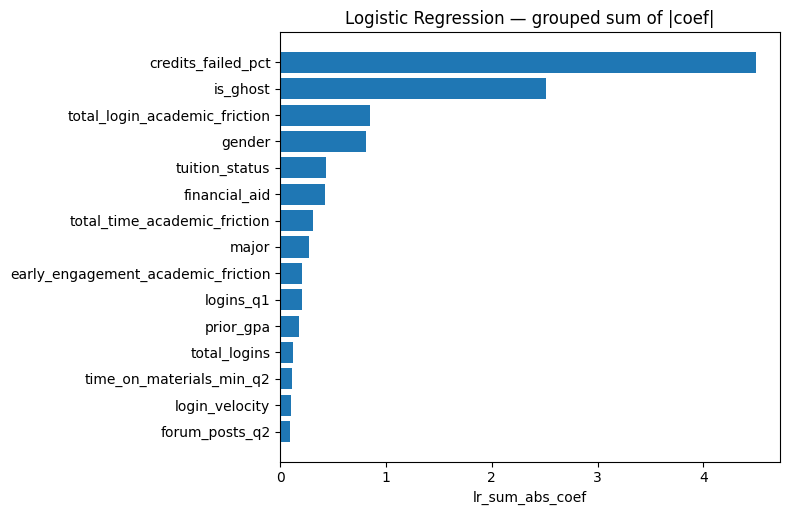

--- XGBoost: grouped feature importance (top 15) ---


,feature,n_components,xgb_sum_importance
24,total_time_academic_friction,1,0.618027
6,credits_failed_pct,1,0.046674
0,major,4,0.045359
2,financial_aid,4,0.041176
3,tuition_status,3,0.030423
19,total_time,1,0.024355
7,logins_q1,1,0.021716
1,gender,4,0.013076
17,time_velocity,1,0.013074
18,total_logins,1,0.011411


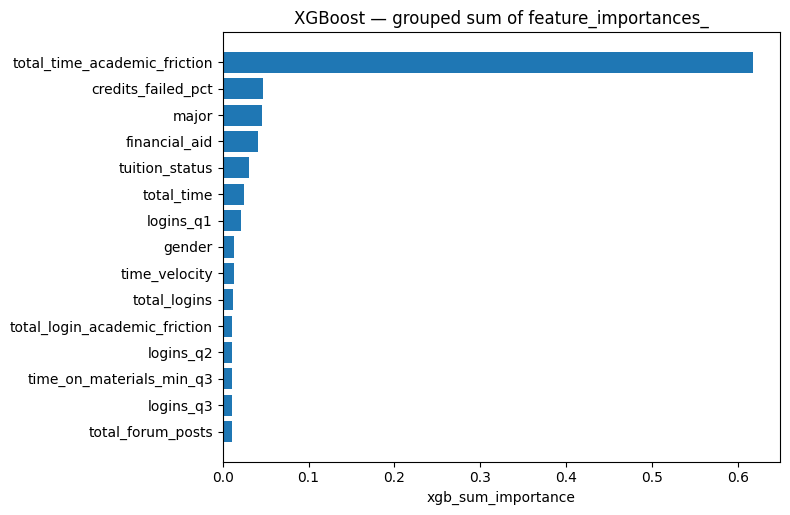

In [ ]:
def raw_column_index_spans(preprocess, cat_cols_raw, num_cols_raw):
    """Map each raw column to indices in preprocess.transform() output (cat block, then num)."""
    ohe = preprocess.named_transformers_["cat"]
    spans = {}
    idx = 0
    for i, col in enumerate(cat_cols_raw):
        n = len(ohe.categories_[i])
        spans[col] = list(range(idx, idx + n))
        idx += n
    for col in num_cols_raw:
        spans[col] = [idx]
        idx += 1
    n_out = len(preprocess.get_feature_names_out())
    if idx != n_out:
        raise ValueError(
            f"Feature index walk ({idx}) != get_feature_names_out length ({n_out})."
        )
    return spans


def grouped_importance_df(pipe, spans, model_kind):
    """model_kind: 'lr' -> sum |coef|; 'xgb' -> sum feature_importances_."""
    preprocess = pipe.named_steps["preprocess"]
    model = pipe.named_steps["model"]
    n_feat = len(preprocess.get_feature_names_out())
    if model_kind == "lr":
        w = np.asarray(model.coef_, dtype=float).ravel()
        col_score = "lr_sum_abs_coef"
        scores = {c: float(np.abs(w[spans[c]]).sum()) for c in spans}
    elif model_kind == "xgb":
        w = np.asarray(model.feature_importances_, dtype=float).ravel()
        col_score = "xgb_sum_importance"
        scores = {c: float(w[spans[c]].sum()) for c in spans}
    else:
        raise ValueError("model_kind must be 'lr' or 'xgb'")
    if len(w) != n_feat:
        raise ValueError(
            f"{model_kind}: weight length {len(w)} != preprocess output {n_feat}"
        )
    df_imp = pd.DataFrame(
        [
            {"feature": c, "n_components": len(spans[c]), col_score: scores[c]}
            for c in spans
        ]
    )
    return df_imp.sort_values(col_score, ascending=False), col_score


def plot_top_features(df_imp, score_col, title, top_k=15):
    top = df_imp.head(top_k).iloc[::-1]
    fig, ax = plt.subplots(figsize=(8, max(3, 0.35 * len(top))))
    ax.barh(top["feature"], top[score_col])
    ax.set_xlabel(score_col)
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


top_k = 10

# Same raw layout for both pipelines (same train data / column order)
spans_lr = raw_column_index_spans(
    lr_pipe.named_steps["preprocess"], cat_cols_raw, num_cols_raw
)
spans_xgb = raw_column_index_spans(
    xgb_pipe.named_steps["preprocess"], cat_cols_raw, num_cols_raw
)
assert spans_lr.keys() == spans_xgb.keys()
for k in spans_lr:
    assert spans_lr[k] == spans_xgb[k], k

df_lr_imp, lr_col = grouped_importance_df(lr_pipe, spans_lr, "lr")
df_xgb_imp, xgb_col = grouped_importance_df(xgb_pipe, spans_xgb, "xgb")

print("--- Logistic Regression: grouped |coefficient| (top {}) ---".format(top_k))
display(df_lr_imp.head(top_k))
plot_top_features(df_lr_imp, lr_col, "Logistic Regression — grouped sum of |coef|", top_k)

print("--- XGBoost: grouped feature importance (top {}) ---".format(top_k))
display(df_xgb_imp.head(top_k))
plot_top_features(df_xgb_imp, xgb_col, "XGBoost — grouped sum of feature_importances_", top_k)

### SHAP values (XGBoost)

[SHAP](https://github.com/shap/shap) (SHapley Additive exPlanations) summarizes how much each **preprocessed** feature pushes the model’s output **up or down** from the baseline, for each student.

Here we use **`TreeExplainer`**, which is exact and fast for tree ensembles. The model is the fitted **`XGBClassifier`** inside `xgb_pipe`; inputs are the **same transformed matrix** the trees see (one-hot columns + numeric passthrough). For this binary setup, values correspond to **dropout risk (positive class 1)**.

We use a **random background** subset of training rows (for the explainer baseline) and explain a **subset of the test set** so the notebook stays responsive. Re-run with larger samples if you need smoother estimates.

**Requires:** `pip install shap` (once per environment).

C:\Users\tbaug\AppData\Local\Temp\ipykernel_500\340506612.py:23: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


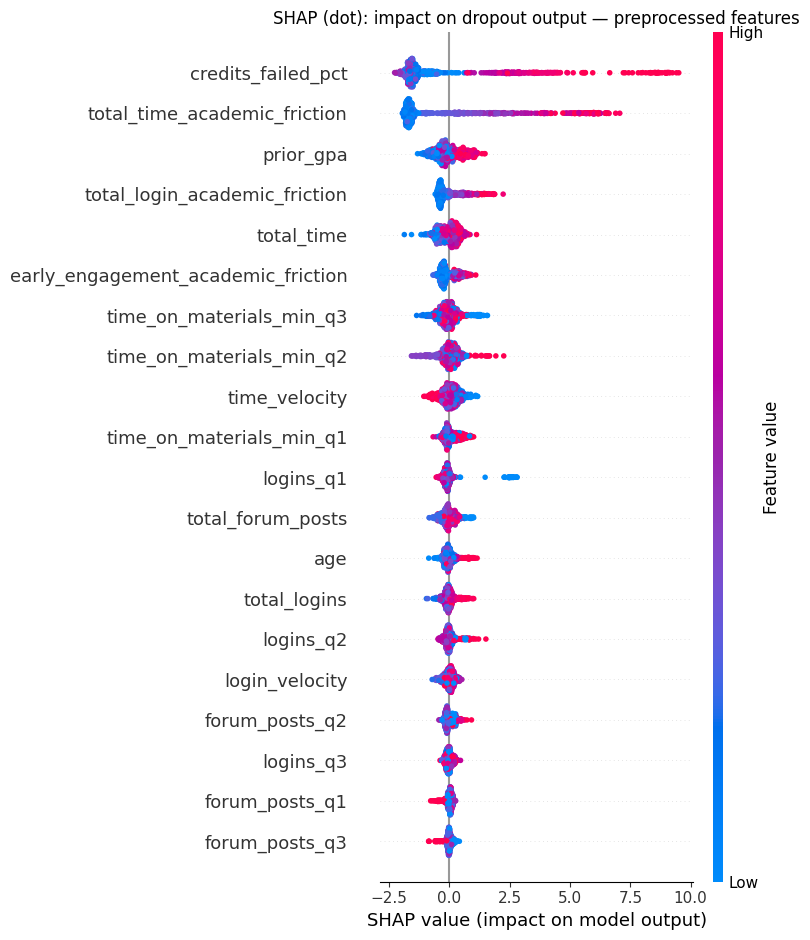

C:\Users\tbaug\AppData\Local\Temp\ipykernel_500\340506612.py:36: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


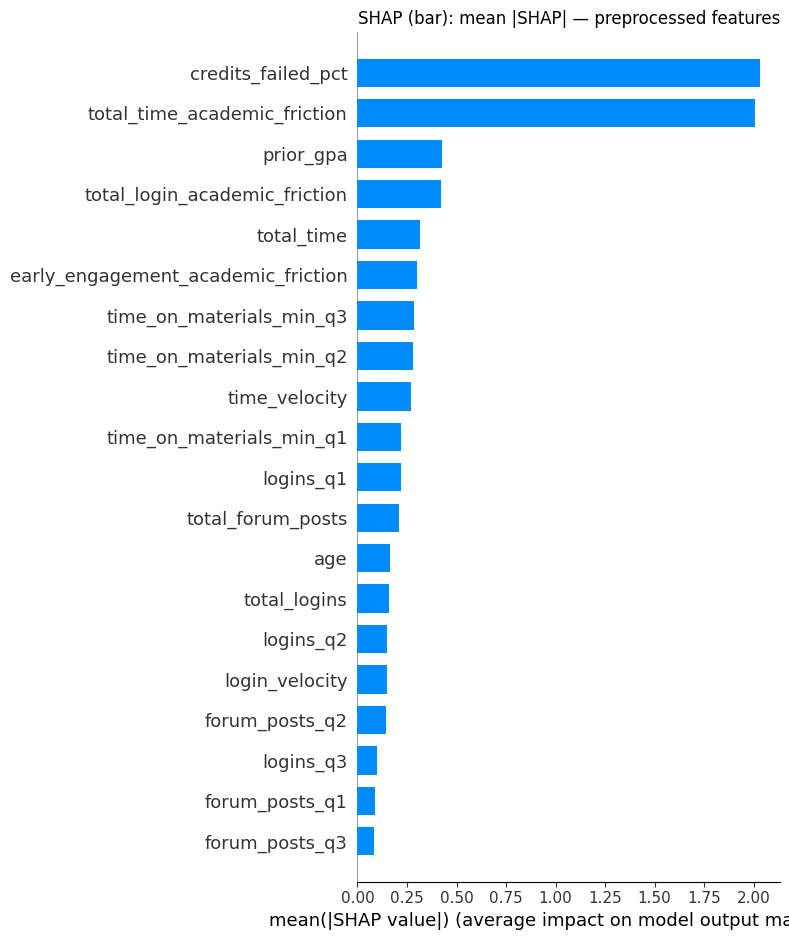

Grouped mean |SHAP| (sum across one-hot columns per raw variable):


,feature,n_components,mean_abs_shap_sum
0,credits_failed_pct,1,2.031262
1,total_time_academic_friction,1,2.007094
2,prior_gpa,1,0.428891
3,total_login_academic_friction,1,0.420870
4,total_time,1,0.315454
5,early_engagement_academic_friction,1,0.300739
6,time_on_materials_min_q3,1,0.286489
7,time_on_materials_min_q2,1,0.277892
8,time_velocity,1,0.268523
9,financial_aid,4,0.242570


In [7]:
# SHAP for xgb_pipe: explain on preprocessed features (same space as the trees)
_preprocess = xgb_pipe.named_steps["preprocess"]
_xgb_model = xgb_pipe.named_steps["model"]
feat_names_shap = list(_preprocess.get_feature_names_out())

X_train_t = _preprocess.transform(X_train)
X_test_t = _preprocess.transform(X_test)

rng = np.random.default_rng(RANDOM_STATE)
bg_n = min(200, X_train_t.shape[0])
bg_idx = rng.choice(X_train_t.shape[0], size=bg_n, replace=False)
X_bg = X_train_t[bg_idx]

explainer_shap = shap.TreeExplainer(_xgb_model, X_bg)

n_explain = min(800, X_test_t.shape[0])
X_explain_t = X_test_t[:n_explain]

explanation = explainer_shap(X_explain_t)
shap_values = explanation.values

plt.figure()
shap.summary_plot(
    shap_values,
    X_explain_t,
    feature_names=feat_names_shap,
    plot_type="dot",
    max_display=20,
    show=False,
)
plt.title("SHAP (dot): impact on dropout output — preprocessed features")
plt.tight_layout()
plt.show()

plt.figure()
shap.summary_plot(
    shap_values,
    X_explain_t,
    feature_names=feat_names_shap,
    plot_type="bar",
    max_display=20,
    show=False,
)
plt.title("SHAP (bar): mean |SHAP| — preprocessed features")
plt.tight_layout()
plt.show()

# Group mean |SHAP| by raw column (same index blocks as grouped feature importance)
spans_shap = raw_column_index_spans(_preprocess, cat_cols_raw, num_cols_raw)
mean_abs = np.abs(shap_values).mean(axis=0)
df_shap_grouped = (
    pd.DataFrame(
        [
            {
                "feature": col,
                "n_components": len(spans_shap[col]),
                "mean_abs_shap_sum": float(mean_abs[spans_shap[col]].sum()),
            }
            for col in spans_shap
        ]
    )
    .sort_values("mean_abs_shap_sum", ascending=False)
    .reset_index(drop=True)
)
print("Grouped mean |SHAP| (sum across one-hot columns per raw variable):")
display(df_shap_grouped.head(15))

In [8]:
# Analyze XGBoost predictions for distribution of errors across majors to ensure overfitting has not occured on a majority class.
pred = y_pred_xgb

eval_df = pd.DataFrame({
    "major": X_test["major"],
    "y_true": y_test,   # dropout=1
    "y_pred": pred,
})
eval_df["wrong"] = eval_df["y_true"] != eval_df["y_pred"]

summary = (
    eval_df.groupby("major")
    .agg(
        n_test=("major", "size"),
        n_wrong=("wrong", "sum"),
    )
)
summary["error_rate"] = (summary["n_wrong"] / summary["n_test"]).round(3)

print("Wrong predictions by major (sorted by count wrong):")
display(summary.sort_values("n_wrong", ascending=False))

print("\nWrong predictions by major (sorted by error rate):")
display(summary.sort_values("error_rate", ascending=False))


Wrong predictions by major (sorted by count wrong):


,n_test,n_wrong,error_rate
major,,,
Computer Science,703,31,0.044
Arts,284,16,0.056
Mathematics,235,16,0.068
Business,258,10,0.039



Wrong predictions by major (sorted by error rate):


,n_test,n_wrong,error_rate
major,,,
Mathematics,235,16,0.068
Arts,284,16,0.056
Computer Science,703,31,0.044
Business,258,10,0.039


Result: Because we had nearly three times as many Computer Science students in our data as any other major, we checked to make sure the model wasn't just guessing well for CS students and failing everyone else. The results show the model performed beautifully across the board. The error rates for all majors were highly consistent, ranging only from 3.9% to 6.8%. This indicates that the model generalized well across different academic disciplines and did not sacrifice minority class performance to favor the majority. 

In [9]:
# Analyze model's ability to predict "Ghost" subgroup on test set
mask = (X_test["is_ghost"] == 1).to_numpy()
y_true_g = y_test.to_numpy()[mask]
y_pred_g = y_pred_xgb[mask]

n_g = int(mask.sum())
print(f"Test rows with is_ghost==1: {n_g}")

if n_g == 0:
    print("No ghost students in test set; skip subgroup metrics.")
else:
    print(f"Dropout recall (ghosts): {recall_score(y_true_g, y_pred_g, pos_label=1):.3f}")
    print(f"Dropout precision (ghosts): {precision_score(y_true_g, y_pred_g, pos_label=1, zero_division=0):.3f}")
    print("\nConfusion matrix [rows=true 0,1 | cols=pred 0,1]:")
    print(confusion_matrix(y_true_g, y_pred_g, labels=[0, 1]))



Test rows with is_ghost==1: 63
Dropout recall (ghosts): 0.982
Dropout precision (ghosts): 0.887

Confusion matrix [rows=true 0,1 | cols=pred 0,1]:
[[ 0  7]
 [ 1 55]]


Result: We specifically tested how well the model predicts outcomes for our "ghost" students—those who are completely digitally disengaged. Out of 63 ghost students in the test set, the model successfully caught 55 out of the 56 students who actually went on to drop out (a 98.2% success rate). It only yielded 7 false alarms. This proves that the model is incredibly reliable at finding at-risk students even when they leave no digital footprint, making it a highly trustworthy tool for targeted outreach.

The "Ghost" Paradox
This subgroup analysis reveals a fascinating paradox regarding digitally disengaged "ghost" students. On paper, ghosts appear academically identical to their active peers, showing no statistically significant differences in prior GPA or credit failure rates. However, their actual outcomes tell a drastically different story: while the overall dropout rate in the test set is just under 15%, a staggering 88.9\% of ghost students (56 out of 63) ended up dropping out. This proves that digital disengagement is one of the strongest behavioral indicators of dropout risk, independent of a student's past academic performance. Because the XGBoost model maintained a 98.2% recall rate on this highly vulnerable group, it stands as an invaluable early-warning tool for counselors to intervene before these silent struggles lead to withdrawal.